In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("dataset/seasonal_agriculture_performance_dataset.csv")

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

Shape: (4000, 28)

Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [55]:
# Check the unique values in the main categorical columns

for col in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"\n{col}:")
    print(df[col].unique())
    print("Number of unique values:", df[col].nunique())


State:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']
Number of unique values: 8

District:
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']
Number of unique values: 10

Crop:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']
Number of unique values: 8

Season:
['Kharif' 'Rabi' 'Zaid']
Number of unique values: 3

Irrigation_Method:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']
Number of unique values: 4


In [56]:
# STEP 3: DATA QUALITY CHECK

print("Missing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:", df.isnull().sum().sum())



Missing Values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest

In [57]:
print("\nDuplicate Rows:")
print("Number of duplicate rows:", df.duplicated().sum())

print("\nBasic Statistical Summary:")
display(df.describe().T)


Duplicate Rows:
Number of duplicate rows: 0

Basic Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [58]:
# STEP4.1: Numerical Variable Analysis

numerical_cols = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

display(df[numerical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [59]:
# Check possible extreme values using selected percentiles

percentiles = df[numerical_cols].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

display(percentiles)

,0.01,0.05,0.25,0.50,0.75,0.95,0.99
Farm_Area_Hectares,0.64000,1.24000,4.260,7.8950,11.65000,1.435050e+01,1.489000e+01
Rainfall_mm,80.00000,147.63500,370.200,582.0000,834.95000,1.075635e+03,1.203698e+03
Avg_Temperature_C,18.59900,20.70000,23.900,26.9000,29.60000,3.300000e+01,3.510000e+01
Humidity_pct,35.50000,43.90000,54.775,63.0000,71.90000,8.280000e+01,8.940400e+01
Sunlight_Hours_Day,4.89900,5.50000,6.600,7.3000,8.10000,9.200000e+00,1.000000e+01
Soil_pH,5.20000,5.64000,6.260,6.6900,7.14000,7.780000e+00,8.240100e+00
Soil_Moisture_pct,11.40000,15.59500,21.700,26.4000,31.30000,3.730000e+01,4.100000e+01
Nitrogen_kg_ha,47.59300,68.49500,98.500,120.1000,141.22500,1.713000e+02,1.906040e+02
Phosphorus_kg_ha,17.29800,30.00000,46.200,57.5000,69.40000,8.640000e+01,9.710100e+01
Potassium_kg_ha,38.59200,57.69500,86.200,105.1000,123.60000,1.492000e+02,1.689030e+02


In [60]:
#STEP 4.2: Identify potential outliers using IQR

outlier_cols = [
    'Farm_Area_Hectares',
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Lower_Bound': lower,
        'Upper_Bound': upper,
        'Outlier_Count': outliers,
        'Outlier_Percentage': round((outliers / len(df)) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values(
    by='Outlier_Count',
    ascending=False
))

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
10,Profit_INR,-696111.000000,7.635670e+05,404,10.10
6,Production_Tonnes,-23.982500,5.335750e+01,333,8.33
12,Water_Efficiency_t_per_1000m3,-3.572875,1.038412e+01,322,8.05
5,Yield_Tonnes_Ha,-1.635000,5.525000e+00,302,7.55
11,Water_Used_m3,-6072.750000,1.617125e+04,276,6.90
9,Revenue_INR,-736519.000000,1.780911e+06,240,6.00
13,Disease_Pest_Risk_pct,10.900000,8.130000e+01,10,0.25
3,Humidity_pct,29.087500,9.758750e+01,6,0.15
4,Soil_Moisture_pct,7.300000,4.570000e+01,3,0.08
2,Avg_Temperature_C,15.350000,3.815000e+01,2,0.05


In [61]:
#STEP 4.3: Inspect extreme agricultural performance records

cols_to_check = [
    'Farm_ID',
    'State',
    'District',
    'Crop',
    'Season',
    'Farm_Area_Hectares',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3'
]

print("Top 10 highest Yield:")
display(df[cols_to_check].nlargest(10, 'Yield_Tonnes_Ha'))

print("\nTop 10 highest Production:")
display(df[cols_to_check].nlargest(10, 'Production_Tonnes'))

print("\nTop 10 highest Profit:")
display(df[cols_to_check].nlargest(10, 'Profit_INR'))

Top 10 highest Yield:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,3077,364374,1972665,1608291,11781,54.418
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,2917,419212,1890741,1471529,10705,60.549
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,3839,484604,2701312,2216708,12787,55.029
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,3898,58030,292350,234320,1944,38.580
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,3316,495312,1732113,1236801,12199,42.819
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,3705,491085,2475903,1984818,11547,57.873
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,3625,395192,2436870,2041678,12526,53.668
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,3060,435000,1635815,1200815,11086,48.221



Top 10 highest Production:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,13.96,82.68,1154.21,3886,745161,4485260,3740099,23472,49.174
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,14.16,79.25,1122.18,3661,875331,4108301,3232970,21133,53.101
3027,SF13028,Punjab,Warangal,Sugarcane,Rabi,14.97,73.44,1099.40,3288,967925,3614827,2646902,21717,50.624
3750,SF13751,Maharashtra,Krishna,Sugarcane,Kharif,14.99,70.28,1053.50,3393,1013796,3574526,2560730,26177,40.245
762,SF10763,Karnataka,Nalgonda,Sugarcane,Kharif,14.47,70.62,1021.87,3322,1043508,3394652,2351144,36156,28.263
1211,SF11212,Gujarat,Nalgonda,Sugarcane,Kharif,14.85,64.45,957.08,3342,883868,3198561,2314693,20165,47.462
1616,SF11617,Madhya Pradesh,Nashik,Sugarcane,Zaid,14.90,64.21,956.73,3661,1152599,3502589,2349990,19708,48.545
862,SF10863,Maharashtra,Raichur,Sugarcane,Rabi,12.28,77.40,950.47,3464,944405,3292428,2348023,18766,50.649



Top 10 highest Profit:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,12.74,3.90,49.69,101780,712027,5057448,4345421,10398,4.779
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,14.45,2.92,42.19,120429,1059050,5080900,4021850,10980,3.842
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,13.96,82.68,1154.21,3886,745161,4485260,3740099,23472,49.174
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,13.04,3.01,39.25,115222,784135,4522464,3738329,7074,5.548
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,14.86,3.09,45.92,105082,1283161,4825365,3542204,12869,3.568
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3483,972119,4350998,3378879,23936,52.190
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3109,1097878,4428460,3330582,23289,61.162
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,14.16,79.25,1122.18,3661,875331,4108301,3232970,21133,53.101
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,13.68,3.02,41.31,98175,844264,4055609,3211345,7219,5.722
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,13.95,2.53,35.29,112997,828217,3987664,3159447,8108,4.352


In [62]:
# STEP 5: Overall Seasonal Performance

season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median'),
    Avg_Water_Used=('Water_Used_m3', 'mean')
).round(2)

display(season_summary)

,Farms,Avg_Yield,Median_Yield,Avg_Production,Avg_Profit,Median_Profit,Avg_Water_Used
Season,,,,,,,
Kharif,1779,5.64,1.95,46.31,178914.65,38808.0,6102.20
Rabi,1627,5.08,1.66,41.49,87689.47,-3187.0,5846.99
Zaid,594,4.67,1.45,38.89,-24804.82,-62144.0,6419.89


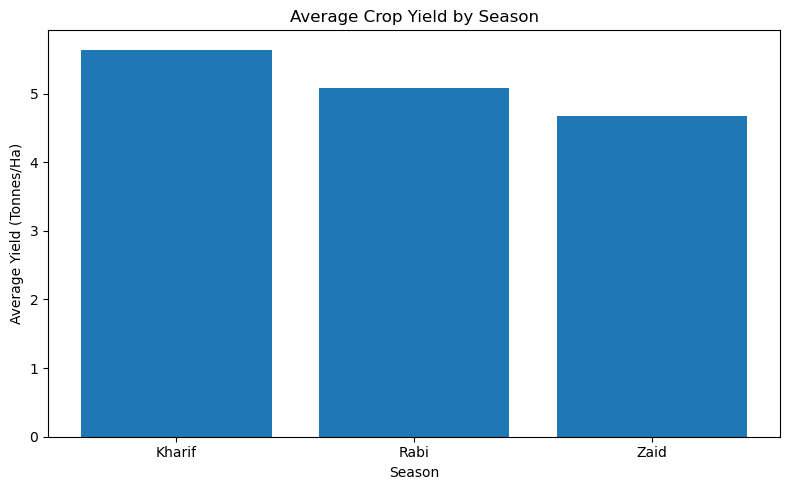

In [63]:
# STEP 5.1: Average Yield by Season

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary['Avg_Yield']
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

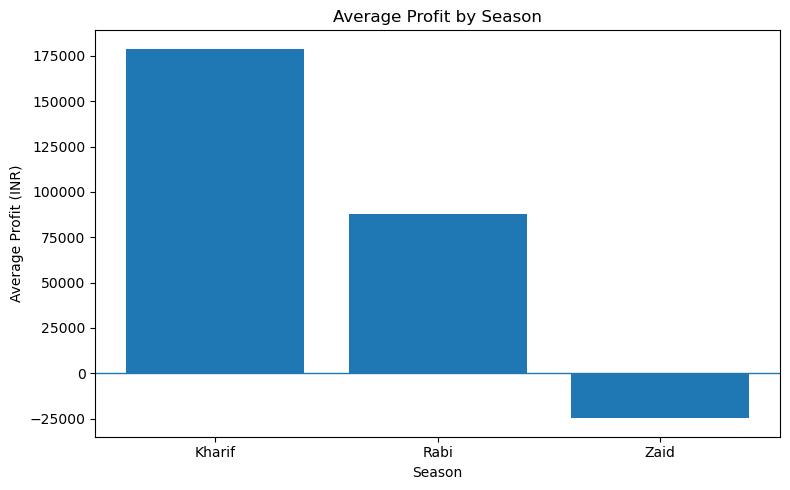

In [64]:
#STEP 5.2: Average Profit by Season

plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary['Avg_Profit']
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

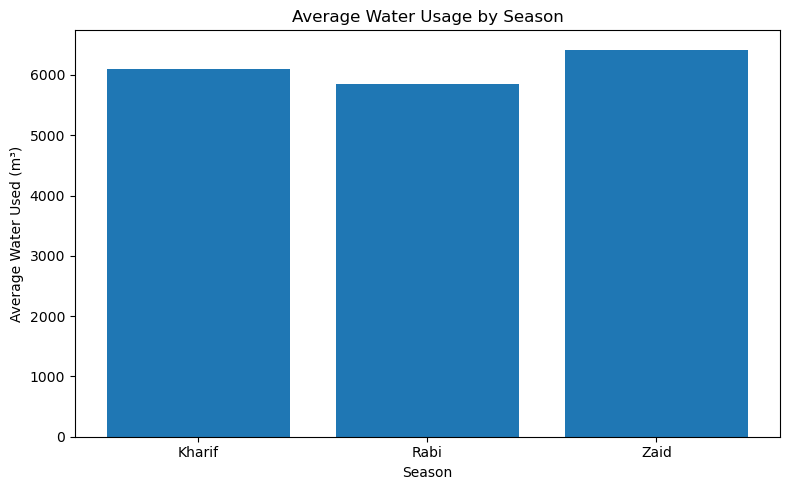

In [65]:
# STEP 5.3: Average Water Usage by Season

plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary['Avg_Water_Used']
)

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

plt.tight_layout()
plt.show()

In [66]:
# STEP5.4: Number of Farms by Season

season_counts = df['Season'].value_counts()

display(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [67]:
# STEP 6: Environmental Conditions by Season

environment_summary = df.groupby('Season').agg(
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Humidity=('Humidity_pct', 'mean'),
    Avg_Sunlight=('Sunlight_Hours_Day', 'mean')
).round(2)

display(environment_summary)

,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Sunlight
Season,,,,
Kharif,852.08,28.45,71.81,6.79
Rabi,436.00,23.49,57.89,7.59
Zaid,299.42,31.04,52.01,8.18


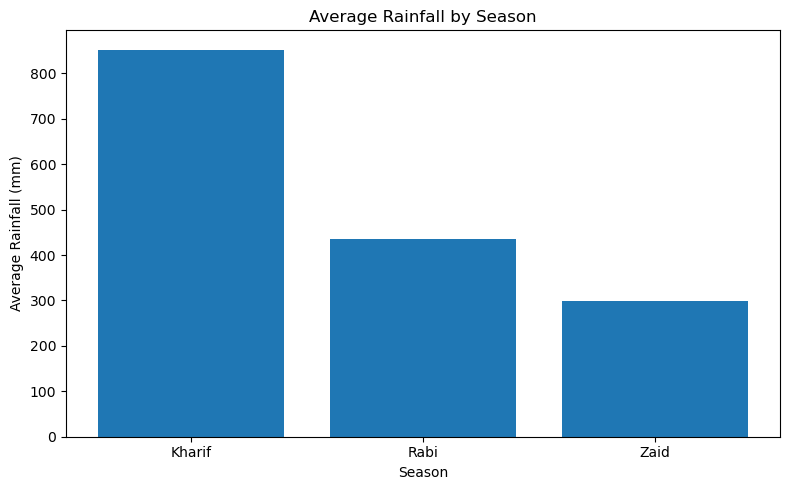

In [68]:
# STEP 6.1: Average Rainfall by Season

plt.figure(figsize=(8, 5))

plt.bar(
    environment_summary.index,
    environment_summary['Avg_Rainfall']
)

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')

plt.tight_layout()
plt.show()

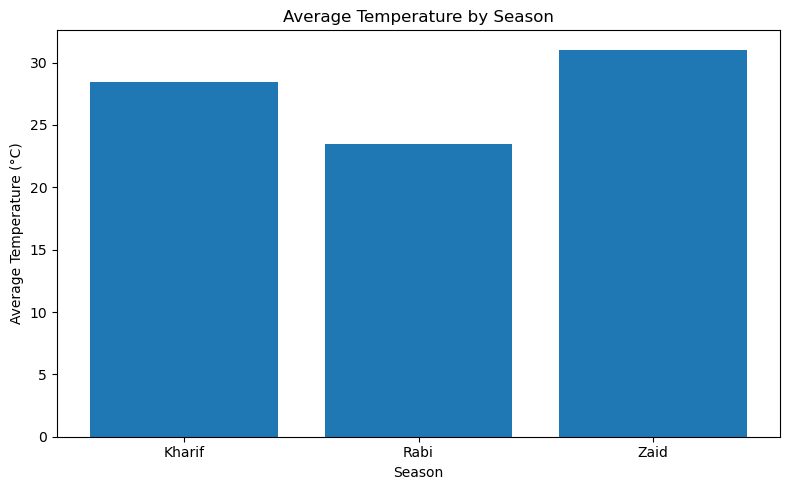

In [69]:
# STEP 6.2: Average Temperature by Season

plt.figure(figsize=(8, 5))

plt.bar(
    environment_summary.index,
    environment_summary['Avg_Temperature']
)

plt.title('Average Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')

plt.tight_layout()
plt.show()

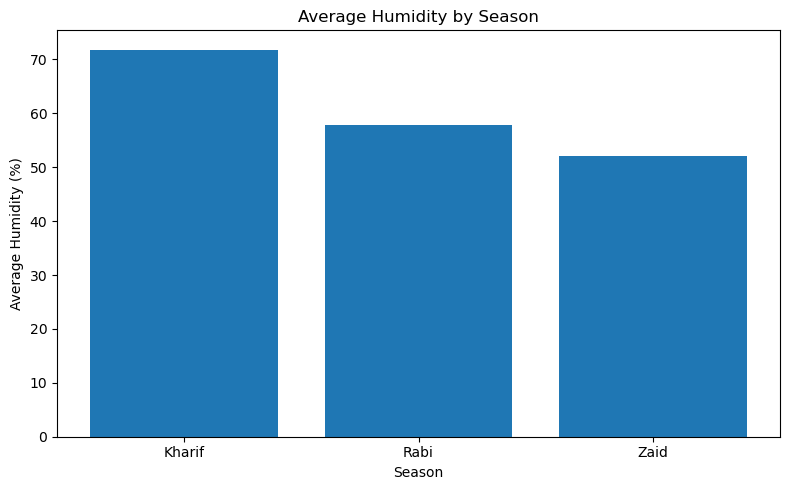

In [70]:
# STEP6.3: Average Humidity by Season

plt.figure(figsize=(8, 5))

plt.bar(
    environment_summary.index,
    environment_summary['Avg_Humidity']
)

plt.title('Average Humidity by Season')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')

plt.tight_layout()
plt.show()

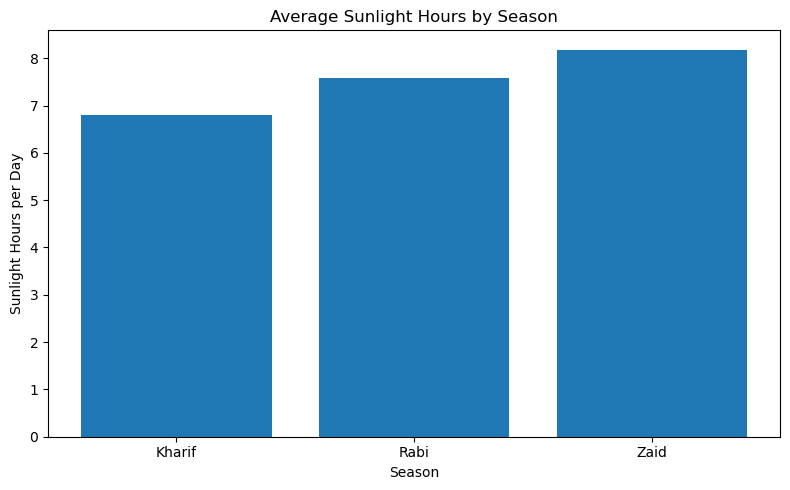

In [71]:
#STEP 6.4: Average Sunlight Hours by Season

plt.figure(figsize=(8, 5))

plt.bar(
    environment_summary.index,
    environment_summary['Avg_Sunlight']
)

plt.title('Average Sunlight Hours by Season')
plt.xlabel('Season')
plt.ylabel('Sunlight Hours per Day')

plt.tight_layout()
plt.show()

In [72]:
# STE 6.5: Environmental Conditions Summary

display(environment_summary)

,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Sunlight
Season,,,,
Kharif,852.08,28.45,71.81,6.79
Rabi,436.00,23.49,57.89,7.59
Zaid,299.42,31.04,52.01,8.18


In [73]:
# Step7.1: Average resource usage by season

resource_summary = df.groupby('Season').agg(
    Avg_Nitrogen=('Nitrogen_kg_ha', 'mean'),
    Avg_Phosphorus=('Phosphorus_kg_ha', 'mean'),
    Avg_Potassium=('Potassium_kg_ha', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean')
).round(2)

display(resource_summary)

,Avg_Nitrogen,Avg_Phosphorus,Avg_Potassium,Avg_Fertilizer,Avg_Pesticide
Season,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08
Rabi,120.40,57.31,103.93,185.41,5.02
Zaid,120.53,58.13,105.42,184.64,5.17


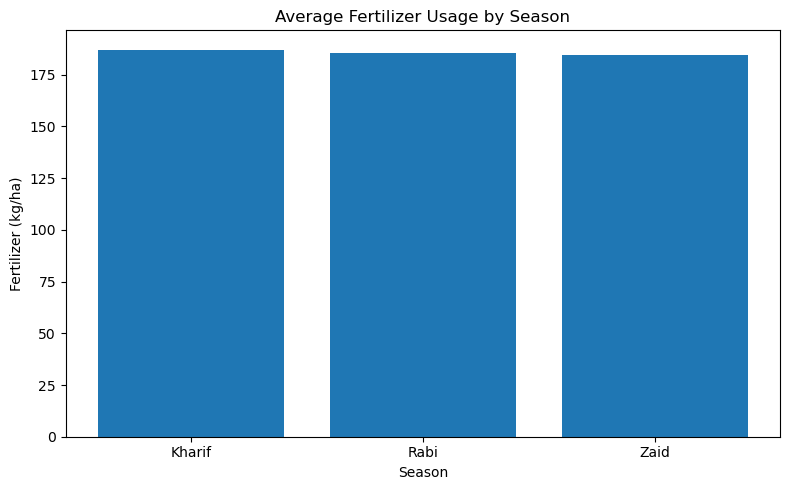

In [74]:
# Step 7.2: Average fertilizer usage by season

plt.figure(figsize=(8, 5))

plt.bar(
    resource_summary.index,
    resource_summary['Avg_Fertilizer']
)

plt.title('Average Fertilizer Usage by Season')
plt.xlabel('Season')
plt.ylabel('Fertilizer (kg/ha)')

plt.tight_layout()
plt.show()

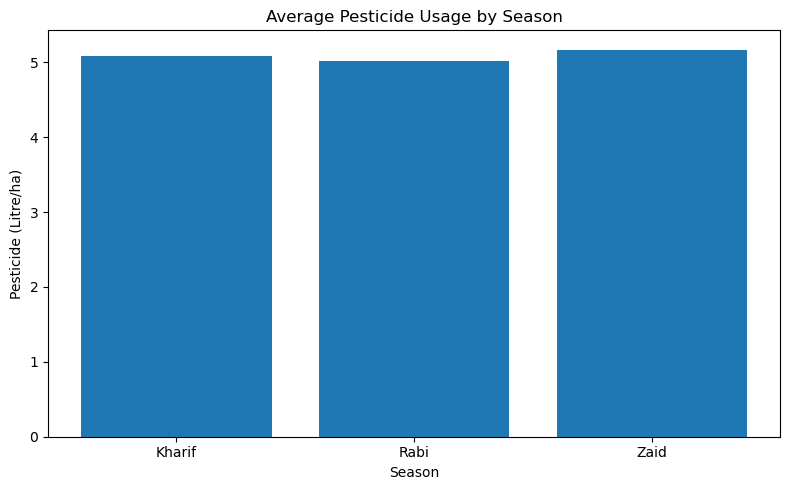

In [75]:
# Step 7.3: Average pesticide usage by season

plt.figure(figsize=(8, 5))

plt.bar(
    resource_summary.index,
    resource_summary['Avg_Pesticide']
)

plt.title('Average Pesticide Usage by Season')
plt.xlabel('Season')
plt.ylabel('Pesticide (Litre/ha)')

plt.tight_layout()
plt.show()

In [76]:
# Step 7.4: Water usage and efficiency by season

water_summary = df.groupby('Season').agg(
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

display(water_summary)

,Avg_Water_Used,Avg_Water_Efficiency
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


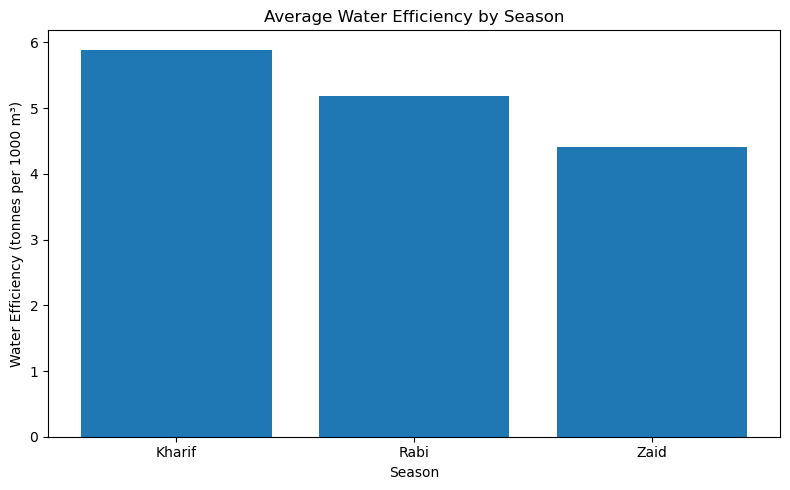

In [77]:
# Step 7.5: Average water efficiency by season

plt.figure(figsize=(8, 5))

plt.bar(
    water_summary.index,
    water_summary['Avg_Water_Efficiency']
)

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (tonnes per 1000 m³)')

plt.tight_layout()
plt.show()

In [78]:
# Step 7.6: Irrigation methods used across seasons

irrigation_season = pd.crosstab(
    df['Season'],
    df['Irrigation_Method']
)

display(irrigation_season)


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


In [79]:
#Step 7.7: Irrigation method distribution (%)

irrigation_percentage = pd.crosstab(
    df['Season'],
    df['Irrigation_Method'],
    normalize='index'
).mul(100).round(2)

display(irrigation_percentage)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


In [80]:
# Step 8.1: Economic performance by season

economic_summary = df.groupby('Season').agg(
    Avg_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Avg_Total_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

display(economic_summary)

,Avg_Market_Price,Avg_Total_Cost,Avg_Revenue,Avg_Profit
Season,,,,
Kharif,44850.91,531804.41,710719.06,178914.65
Rabi,44747.97,513836.58,601526.05,87689.47
Zaid,44212.03,543976.73,519171.90,-24804.82


In [81]:
# Step 8.2: Profit margin by season

df['Profit_Margin_pct'] = (
    df['Profit_INR'] / df['Revenue_INR']
) * 100

profit_margin_summary = df.groupby('Season').agg(
    Avg_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Median_Profit_Margin=('Profit_Margin_pct', 'median')
).round(2)

display(profit_margin_summary)


,Avg_Profit_Margin,Median_Profit_Margin
Season,,
Kharif,-38.64,11.09
Rabi,-44.27,-1.34
Zaid,-69.35,-24.59


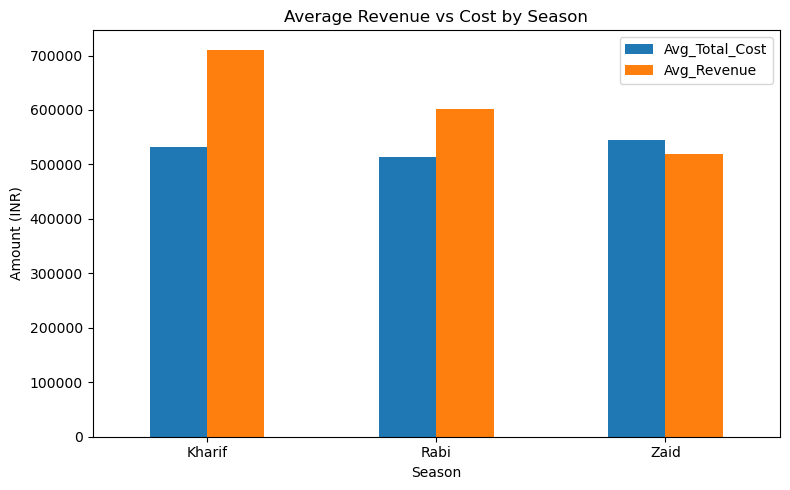

In [82]:
# Step 8.3: Revenue and cost comparison

economic_summary[['Avg_Total_Cost', 'Avg_Revenue']].plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Average Revenue vs Cost by Season')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

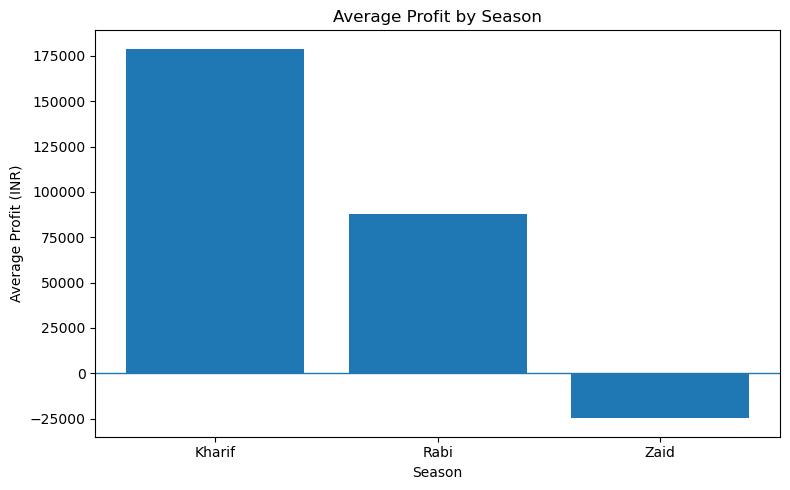

In [83]:
# Step 8.4: Average profit by season

plt.figure(figsize=(8, 5))

plt.bar(
    economic_summary.index,
    economic_summary['Avg_Profit']
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.axhline(0, linewidth=1)

plt.tight_layout()
plt.show()

In [84]:
# Step 8.5: Profitable and loss-making farms by season

df['Profit_Status'] = df['Profit_INR'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss'
)

profit_status = pd.crosstab(
    df['Season'],
    df['Profit_Status']
)

display(profit_status)

Profit_Status,Loss,Profit
Season,,
Kharif,751,1028
Rabi,832,795
Zaid,383,211


In [85]:
# Step 8.6: Profit status percentage

profit_status_pct = pd.crosstab(
    df['Season'],
    df['Profit_Status'],
    normalize='index'
).mul(100).round(2)

display(profit_status_pct)


Profit_Status,Loss,Profit
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


In [86]:
#Step 8.7: Overall profit margin by season

weighted_margin = df.groupby('Season').agg(
    Total_Revenue=('Revenue_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum')
)

weighted_margin['Profit_Margin_pct'] = (
    weighted_margin['Total_Profit']
    / weighted_margin['Total_Revenue']
) * 100

weighted_margin = weighted_margin.round(2)

display(weighted_margin)

,Total_Revenue,Total_Profit,Profit_Margin_pct
Season,,,
Kharif,1264369200,318289158,25.17
Rabi,978682881,142670768,14.58
Zaid,308388111,-14734066,-4.78


In [87]:
#Step 9.1: Overall crop performance

crop_summary = df.groupby('Crop').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Median_Profit=('Profit_INR', 'median')
).round(2)

display(
    crop_summary.sort_values('Avg_Yield', ascending=False)
)

,Farms,Avg_Yield,Median_Yield,Avg_Production,Avg_Profit,Median_Profit
Crop,,,,,,
Sugarcane,305,46.94,48.03,392.41,817187.99,691166.0
Maize,551,2.72,2.85,21.78,-83978.33,-42625.0
Rice,690,2.44,2.46,19.29,-102213.50,-58286.0
Wheat,614,2.11,2.22,16.85,-123398.34,-76269.0
Chilli,412,1.54,1.56,12.38,750878.34,536375.0
Groundnut,424,1.32,1.40,9.66,44858.12,36307.0
Cotton,508,1.23,1.24,9.40,124546.92,62092.5
Pulses,496,0.92,0.94,7.40,-4238.05,2575.5


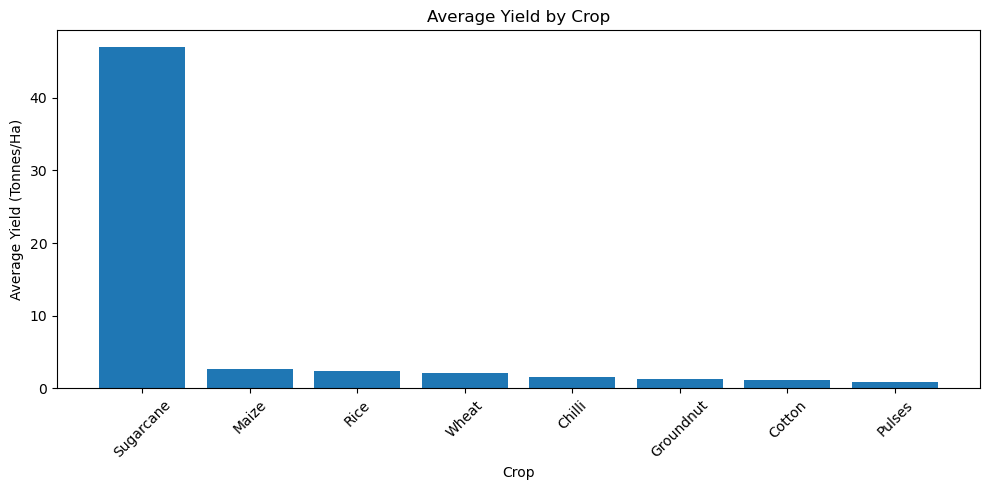

In [88]:
# Step 9.2: Average yield by crop

crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    crop_yield.index,
    crop_yield.values
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

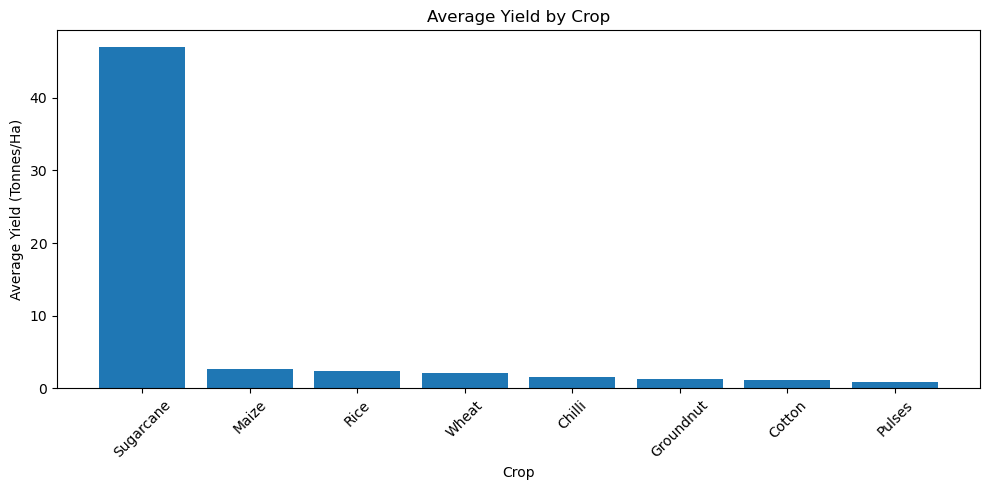

In [89]:
# Step 9.2: Average yield by crop

crop_yield = (
    df.groupby('Crop')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    crop_yield.index,
    crop_yield.values
)

plt.title('Average Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [90]:
# Step 9.3: Crop yield across seasons

crop_season_yield = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

display(crop_season_yield)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


In [91]:
# Step 9.4: Crop profit across seasons

crop_season_profit = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
).round(2)

display(crop_season_profit)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


In [92]:
# Step 9.5: State-wise performance

state_summary = df.groupby('State').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

display(
    state_summary.sort_values('Avg_Yield', ascending=False)
)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,,
Punjab,484,6.12,136025.64,5.62
Karnataka,489,5.73,119422.34,5.56
Gujarat,488,5.70,117568.24,5.58
Telangana,516,5.08,108829.62,5.46
Madhya Pradesh,497,5.03,86840.76,5.27
Maharashtra,512,5.03,135428.86,5.28
Tamil Nadu,485,4.90,117744.75,5.31
Andhra Pradesh,529,4.65,73453.53,5.03


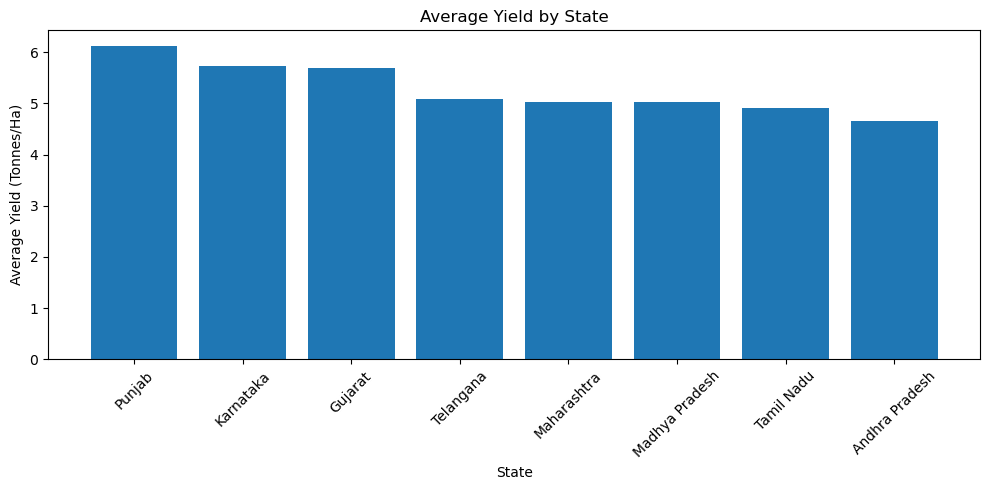

In [93]:
# Step 9.6: Average yield by state

state_yield = (
    df.groupby('State')['Yield_Tonnes_Ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    state_yield.index,
    state_yield.values
)

plt.title('Average Yield by State')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [94]:
# Step 9.7: Number of farms by crop

crop_counts = df['Crop'].value_counts()

display(crop_counts)

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [95]:
# Step 10.1: Correlation with agricultural performance

correlation_cols = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_cols].corr().round(2)

display(correlation_matrix)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Rainfall_mm,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,...,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,...,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,...,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,...,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,...,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01
Fertilizer_kg_ha,0.02,0.02,0.02,-0.01,-0.01,0.01,-0.03,0.01,0.02,1.00,...,0.02,0.00,0.00,-0.00,0.15,0.01,-0.07,0.00,0.01,0.02


In [96]:
# Step 10.2: Variables most related to yield

yield_correlation = (
    correlation_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

display(yield_correlation)

Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Avg_Temperature_C                0.01
Disease_Pest_Risk_pct            0.01
Soil_Moisture_pct                0.01
Humidity_pct                     0.01
Fertilizer_kg_ha                 0.00
Potassium_kg_ha                  0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Soil_pH                         -0.02
Sunlight_Hours_Day              -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

In [97]:
# Step 10.3: Variables most related to profit

profit_correlation = (
    correlation_matrix['Profit_INR']
    .drop('Profit_INR')
    .sort_values(ascending=False)
)

display(profit_correlation)

Revenue_INR                      0.89
Production_Tonnes                0.55
Yield_Tonnes_Ha                  0.49
Water_Efficiency_t_per_1000m3    0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Rainfall_mm                      0.11
Soil_Moisture_pct                0.09
Nitrogen_kg_ha                   0.09
Total_Cost_INR                   0.07
Disease_Pest_Risk_pct            0.07
Humidity_pct                     0.06
Phosphorus_kg_ha                 0.05
Potassium_kg_ha                  0.03
Seed_Quality_Score               0.01
Avg_Temperature_C                0.01
Soil_pH                         -0.01
Pesticide_Litre_ha              -0.03
Sunlight_Hours_Day              -0.05
Fertilizer_kg_ha                -0.07
Name: Profit_INR, dtype: float64

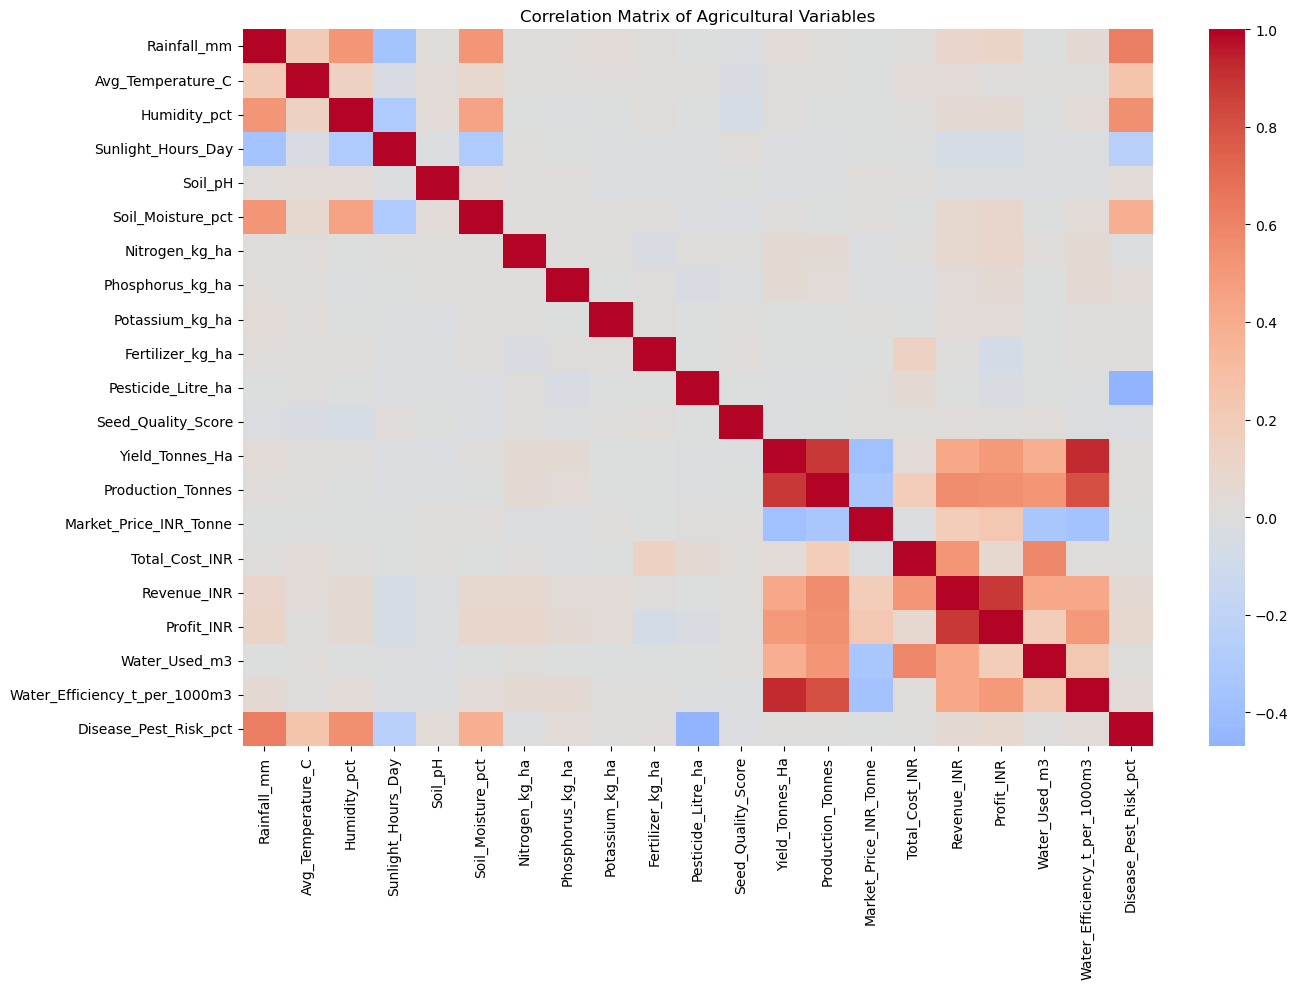

In [98]:
# Step 10.4: Correlation heatmap

import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation_matrix,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.tight_layout()
plt.show()

In [99]:
# Step 11.1: Create a clean copy of the dataset

clean_df = df.copy()

print("Original shape:", clean_df.shape)

#Step 11.2: Remove temporary analysis columns

temporary_cols = ['Profit_Margin_pct', 'Profit_Status']

clean_df = clean_df.drop(
    columns=temporary_cols,
    errors='ignore'
)

print("Shape after removing temporary columns:", clean_df.shape)

# Step 11.3: Check for duplicate records

duplicate_count = clean_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

# Step 11.4: Check missing values before imputation

missing_before = clean_df.isnull().sum()

display(
    missing_before[missing_before > 0]
)

# Step 11.5: Impute missing environmental values using seasonal medians

for column in ['Rainfall_mm', 'Soil_Moisture_pct']:
    clean_df[column] = clean_df[column].fillna(
        clean_df.groupby('Season')[column].transform('median')
    )
    
# Step 11.6: Impute missing yield using crop-season medians

clean_df['Yield_Tonnes_Ha'] = clean_df['Yield_Tonnes_Ha'].fillna(
    clean_df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha']
    .transform('median')
)

# Step 11.7: Verify that missing values have been handled

missing_after = clean_df.isnull().sum()

display(
    missing_after[missing_after > 0]
)

print("Total missing values:", clean_df.isnull().sum().sum())

# Step 11.8: Final duplicate check

print("Duplicate rows:", clean_df.duplicated().sum())

# Step 11.9: Final cleaned dataset

print("Cleaned dataset shape:", clean_df.shape)

display(clean_df.head())

# Step 11.10: Use the cleaned dataset for further analysis

df = clean_df.copy()

print("Final dataset ready for analysis.")
print("Shape:", df.shape)

Original shape: (4000, 30)
Shape after removing temporary columns: (4000, 28)
Duplicate rows: 0


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Series([], dtype: int64)

Total missing values: 0
Duplicate rows: 0
Cleaned dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


Final dataset ready for analysis.
Shape: (4000, 28)


In [100]:
# Step 12.1: Compare seasonal performance

season_comparison = df.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

display(season_comparison)

,Avg_Yield,Avg_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Season,,,,,
Kharif,5.63,46.31,178914.65,6102.20,5.89
Rabi,5.09,41.49,87689.47,5846.99,5.19
Zaid,4.64,38.89,-24804.82,6419.89,4.41


In [101]:
# Step 12.2: Compare other seasons with Kharif

kharif_values = season_comparison.loc['Kharif']

percentage_difference = (
    (season_comparison - kharif_values)
    / kharif_values.abs()
) * 100

percentage_difference = percentage_difference.round(2)

display(percentage_difference)

,Avg_Yield,Avg_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Season,,,,,
Kharif,0.00,0.00,0.00,0.00,0.00
Rabi,-9.59,-10.41,-50.99,-4.18,-11.88
Zaid,-17.58,-16.02,-113.86,5.21,-25.13


In [102]:
# Step 12.3: Seasonal yield difference

yield_difference = (
    season_comparison['Avg_Yield']
    - season_comparison['Avg_Yield'].max()
)

display(
    yield_difference.round(2)
)

# Step 12.4: Seasonal profit difference

profit_difference = (
    season_comparison['Avg_Profit']
    - season_comparison['Avg_Profit'].max()
)

display(
    profit_difference.round(2)
)

Season
Kharif    0.00
Rabi     -0.54
Zaid     -0.99
Name: Avg_Yield, dtype: float64

Season
Kharif         0.00
Rabi      -91225.18
Zaid     -203719.47
Name: Avg_Profit, dtype: float64

In [103]:
# Step 13.1: Prepare yield data for statistical testing

kharif_yield = df.loc[
    df['Season'] == 'Kharif',
    'Yield_Tonnes_Ha'
].dropna()

rabi_yield = df.loc[
    df['Season'] == 'Rabi',
    'Yield_Tonnes_Ha'
].dropna()

zaid_yield = df.loc[
    df['Season'] == 'Zaid',
    'Yield_Tonnes_Ha'
].dropna()

print("Kharif:", len(kharif_yield))
print("Rabi:", len(rabi_yield))
print("Zaid:", len(zaid_yield))

# Step 13.2: Test whether yield differs across seasons

from scipy.stats import f_oneway

anova_yield = f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA F-statistic:", round(anova_yield.statistic, 4))
print("ANOVA p-value:", anova_yield.pvalue)

Kharif: 1779
Rabi: 1627
Zaid: 594
ANOVA F-statistic: 1.4579
ANOVA p-value: 0.2328474889882346


In [104]:
# Step 13.3: Interpret the ANOVA result

alpha = 0.05

if anova_yield.pvalue < alpha:
    print("The difference in yield across seasons is statistically significant.")
else:
    print("The difference in yield across seasons is not statistically significant.")

The difference in yield across seasons is not statistically significant.


In [105]:
# Step 13.4: Test whether profit differs across seasons

kharif_profit = df.loc[
    df['Season'] == 'Kharif',
    'Profit_INR'
].dropna()

rabi_profit = df.loc[
    df['Season'] == 'Rabi',
    'Profit_INR'
].dropna()

zaid_profit = df.loc[
    df['Season'] == 'Zaid',
    'Profit_INR'
].dropna()

anova_profit = f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("ANOVA F-statistic:", round(anova_profit.statistic, 4))
print("ANOVA p-value:", anova_profit.pvalue)

ANOVA F-statistic: 34.2918
ANOVA p-value: 1.7124156677360182e-15


In [106]:
# Step 13.5: Interpret the profit ANOVA

if anova_profit.pvalue < alpha:
    print("The difference in profit across seasons is statistically significant.")
else:
    print("The difference in profit across seasons is not statistically significant.")

The difference in profit across seasons is statistically significant.


In [108]:
# Step 13.6: Post-hoc comparison of seasonal profit

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_profit = pairwise_tukeyhsd(
    endog=df['Profit_INR'],
    groups=df['Season'],
    alpha=0.05
)

print(tukey_profit)

# Step 13.7: Robust statistical check for seasonal profit

from scipy.stats import kruskal

kruskal_profit = kruskal(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Kruskal-Wallis statistic:", round(kruskal_profit.statistic, 4))
print("Kruskal-Wallis p-value:", kruskal_profit.pvalue)

       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------
Kruskal-Wallis statistic: 101.9261
Kruskal-Wallis p-value: 7.362721866797111e-23


In [109]:
# Step 13.8: Interpret the Kruskal-Wallis test

if kruskal_profit.pvalue < 0.05:
    print("The seasonal difference in profit remains statistically significant.")
else:
    print("The seasonal difference in profit is not statistically significant.")

The seasonal difference in profit remains statistically significant.


In [112]:
# Step 14.1: Best and worst season by average profit

best_season = season_comparison['Avg_Profit'].idxmax()
worst_season = season_comparison['Avg_Profit'].idxmin()

print("Best season by average profit:", best_season)
print("Worst season by average profit:", worst_season)

# Step 14.2: Best and worst crop by average yield

best_crop = crop_summary['Avg_Yield'].idxmax()
worst_crop = crop_summary['Avg_Yield'].idxmin()

print("Highest-yielding crop:", best_crop)
print("Lowest-yielding crop:", worst_crop)
# Step 14.3: Best and worst state by average yield

best_state = state_summary['Avg_Yield'].idxmax()
worst_state = state_summary['Avg_Yield'].idxmin()

print("Highest-yielding state:", best_state)
print("Lowest-yielding state:", worst_state)

# Step 14.4: Best and worst season by water efficiency

best_water_season = water_summary['Avg_Water_Efficiency'].idxmax()
worst_water_season = water_summary['Avg_Water_Efficiency'].idxmin()

print("Most water-efficient season:", best_water_season)
print("Least water-efficient season:", worst_water_season)


Best season by average profit: Kharif
Worst season by average profit: Zaid
Highest-yielding crop: Sugarcane
Lowest-yielding crop: Pulses
Highest-yielding state: Punjab
Lowest-yielding state: Andhra Pradesh
Most water-efficient season: Kharif
Least water-efficient season: Zaid


In [113]:
# Step 15.1: Final seasonal performance summary

final_season_summary = df.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Used=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

display(final_season_summary)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Season,,,,,
Kharif,1779,5.63,178914.65,6102.20,5.89
Rabi,1627,5.09,87689.47,5846.99,5.19
Zaid,594,4.64,-24804.82,6419.89,4.41


In [114]:
# Step 15.2: Final environmental comparison

final_environment_summary = df.groupby('Season').agg(
    Avg_Rainfall=('Rainfall_mm', 'mean'),
    Avg_Temperature=('Avg_Temperature_C', 'mean'),
    Avg_Humidity=('Humidity_pct', 'mean'),
    Avg_Sunlight=('Sunlight_Hours_Day', 'mean')
).round(2)

display(final_environment_summary)

,Avg_Rainfall,Avg_Temperature,Avg_Humidity,Avg_Sunlight
Season,,,,
Kharif,852.11,28.45,71.81,6.79
Rabi,435.94,23.49,57.89,7.59
Zaid,299.12,31.04,52.01,8.18


In [115]:
# Step 15.3: Final economic comparison

final_economic_summary = df.groupby('Season').agg(
    Total_Revenue=('Revenue_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

display(final_economic_summary)

,Total_Revenue,Total_Profit,Avg_Revenue,Avg_Profit
Season,,,,
Kharif,1264369200,318289158,710719.06,178914.65
Rabi,978682881,142670768,601526.05,87689.47
Zaid,308388111,-14734066,519171.90,-24804.82


In [116]:
# Step 15.4: Final crop-season performance

final_crop_season = df.groupby(
    ['Season', 'Crop']
).agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

display(final_crop_season)

Avg_Yield  Avg_Profit
Season Crop                            
Kharif Chilli          1.73   954380.42
       Cotton          1.37   216999.55
       Groundnut       1.48   108265.44
       Maize           2.97   -39332.67
       Pulses          1.04    43338.90
       Rice            2.71   -64903.40
       Sugarcane      53.46  1000790.81
       Wheat           2.26  -105871.87
Rabi   Chilli          1.46   638572.50
       Cotton          1.19   107343.59
       Groundnut       1.22    10416.54
       Maize           2.62   -89133.40
       Pulses          0.87   -14309.14
       Rice            2.33   -98427.87
       Sugarcane      43.96   731612.86
       Wheat           2.06  -119954.57
Zaid   Chilli          1.18   448659.09
       Cotton          0.95   -53925.34
       Groundnut       1.04   -68872.50
       Maize           2.30  -194049.17
       Pulses          0.65  -139227.81
       Rice            1.90  -227239.34
       Sugarcane      38.42   583635.80
       Wheat           1.75  -193208.95

In [117]:
# Step 15.5: Final state comparison

final_state_summary = df.groupby('State').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean')
).round(2)

display(
    final_state_summary.sort_values(
        'Avg_Profit',
        ascending=False
    )
)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Efficiency
State,,,,
Punjab,484,6.12,136025.64,5.62
Maharashtra,512,5.02,135428.86,5.28
Karnataka,489,5.78,119422.34,5.56
Tamil Nadu,485,4.87,117744.75,5.31
Gujarat,488,5.75,117568.24,5.58
Telangana,516,5.05,108829.62,5.46
Madhya Pradesh,497,4.99,86840.76,5.27
Andhra Pradesh,529,4.63,73453.53,5.03


In [118]:
# Step 15.6: Final profitability distribution

final_profit_status = pd.crosstab(
    df['Season'],
    df['Profit_INR'] > 0,
    normalize='index'
).mul(100).round(2)

final_profit_status.columns = [
    'Loss_Percentage',
    'Profit_Percentage'
]

display(final_profit_status)

,Loss_Percentage,Profit_Percentage
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


In [119]:
# Step 16.1: Final key findings

final_findings = pd.DataFrame({
    'Finding': [
        'Best season by average profit',
        'Worst season by average profit',
        'Highest-yielding crop',
        'Lowest-yielding crop',
        'Highest-yielding state',
        'Lowest-yielding state',
        'Most water-efficient season',
        'Least water-efficient season'
    ],
    'Result': [
        best_season,
        worst_season,
        best_crop,
        worst_crop,
        best_state,
        worst_state,
        best_water_season,
        worst_water_season
    ]
})

display(final_findings)

,Finding,Result
0,Best season by average profit,Kharif
1,Worst season by average profit,Zaid
2,Highest-yielding crop,Sugarcane
3,Lowest-yielding crop,Pulses
4,Highest-yielding state,Punjab
5,Lowest-yielding state,Andhra Pradesh
6,Most water-efficient season,Kharif
7,Least water-efficient season,Zaid


In [120]:
# Step 16.2: Statistical test summary

statistical_summary = pd.DataFrame({
    'Test': [
        'One-way ANOVA - Yield',
        'One-way ANOVA - Profit',
        'Kruskal-Wallis - Profit'
    ],
    'Statistic': [
        anova_yield.statistic,
        anova_profit.statistic,
        kruskal_profit.statistic
    ],
    'P_Value': [
        anova_yield.pvalue,
        anova_profit.pvalue,
        kruskal_profit.pvalue
    ]
})

statistical_summary = statistical_summary.round(6)

display(statistical_summary)

,Test,Statistic,P_Value
0,One-way ANOVA - Yield,1.457903,0.232847
1,One-way ANOVA - Profit,34.291750,0.000000
2,Kruskal-Wallis - Profit,101.926055,0.000000


In [121]:
# Step 16.3: Final seasonal comparison table

display(
    final_season_summary
)

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Season,,,,,
Kharif,1779,5.63,178914.65,6102.20,5.89
Rabi,1627,5.09,87689.47,5846.99,5.19
Zaid,594,4.64,-24804.82,6419.89,4.41


In [122]:
# Step 16.4: Final profitability comparison

display(
    final_profit_status
)

,Loss_Percentage,Profit_Percentage
Season,,
Kharif,42.21,57.79
Rabi,51.14,48.86
Zaid,64.48,35.52


# Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 | 2026–2027

**Major Project – Data Analytics**

This project is based on agricultural data collected from different seasons, crops and regions. The main purpose of the project is to understand how agricultural performance changes from one season to another. The analysis looks at factors such as crop yield, profṆit, rainfall, temperature, water usage and other farming-related conditions.

## 1. Introduction

Agriculture is affected by many factors, and seasonal conditions are one of the important ones. Rainfall, temperature, humidity, sunlight, water availability and farming practices can all have an effect on crop production and the overall performance of a farm.

In this project, the agricultural dataset is analysed to understand the differences between Kharif, Rabi and Zaid seasons. Along with seasonal performance, the analysis also looks at crop performance, state-wise differences, resource usage, water efficiency and economic outcomes such as revenue and profit.

## 2. Problem Statement

Agricultural data contains a lot of information, but it is not always easy to understand how farming performance changes between different seasons. Simply looking at the raw data does not clearly show which seasons perform better, where losses occur, or how environmental and resource-related factors differ.

Therefore, this project focuses on analysing the available agricultural data to find useful seasonal patterns, differences and relationships in areas such as yield, production, water usage and profitability.

## 3. Objectives

The main objectives of this project are:

- To understand the agricultural dataset and its different variables.
- To clean and prepare the data before performing the analysis.
- To compare agricultural performance across Kharif, Rabi and Zaid seasons.
- To study how environmental conditions vary between seasons.
- To compare the performance of different crops and states.
- To analyse the use of fertilizers, pesticides and other resources.
- To examine water usage and water efficiency across seasons.
- To study revenue, cost and profit differences between seasons.
- To identify important relationships between agricultural variables.
- To use statistical tests to check whether observed seasonal differences are significant.
- To develop useful findings and recommendations based on the analysis.

## 4. Dataset Overview

The dataset contains 4,000 farm records and 28 variables. It includes information about the location of farms, crops and seasons, environmental conditions, farming resources, production, water usage and financial performance.

The main categorical variables are State, District, Crop, Season and Irrigation Method. The numerical variables include farm area, rainfall, temperature, soil conditions, resource usage, yield, production, revenue, cost, profit and water efficiency.

The dataset covers 8 states, 10 districts, 8 crops and 3 agricultural seasons: Kharif, Rabi and Zaid.

### Dataset Structure

The dataset has the following main groups of variables:

- **Farm and location:** Farm ID, State, District and Farm Area
- **Crop and season:** Crop and Season
- **Environmental conditions:** Rainfall, temperature, humidity and sunlight
- **Soil and resources:** Soil pH, soil moisture, nitrogen, phosphorus, potassium, fertilizer and pesticide usage
- **Production:** Yield and total production
- **Economic factors:** Market price, total cost, revenue and profit
- **Water and risk:** Water usage, water efficiency and disease/pest risk

## 5. Data Loading and Initial Inspection

The dataset was first loaded into a Pandas DataFrame. Before starting the main analysis, the structure of the data was checked to understand the number of records, available columns and their data types.

The initial inspection also helped identify categorical and numerical variables and gave a basic idea of the values present in the dataset.

### Missing Value Check

The missing values were found in:

- Rainfall: 48 values
- Soil Moisture: 40 values
- Yield: 32 values

The missing observations were handled during data preparation, and the final dataset contained no missing values.

### Extreme Values and Outliers

Possible outliers were examined using the IQR method. The analysis showed a relatively large number of potential outliers in variables such as profit, production, water efficiency, yield and water usage.

These observations were not automatically removed because an extreme value does not necessarily mean that the record is incorrect. In an agricultural dataset, some farms may genuinely have much higher production or profit than others.

## 8. Seasonal Analysis

The main focus of this project is to understand how agricultural performance differs across Kharif, Rabi and Zaid seasons.

The seasons were compared using yield, production, profit, water usage and water efficiency. Environmental and economic conditions were also examined to understand some of the differences between the seasons.

### Overall Seasonal Performance

Kharif recorded the highest average yield and average profit among the three seasons. Rabi performed below Kharif, while Zaid had the lowest average yield and recorded a negative average profit.

The results indicate that the overall economic performance of the farms varies considerably between seasons.

### Seasonal Profitability

The proportion of profitable farms was highest in Kharif, where 57.79% of farms recorded a profit.

Rabi had 48.86% profitable farms, while only 35.52% of Zaid farms were profitable. Zaid also had the highest loss percentage at 64.48%.

This shows that profitability is a much bigger concern during the Zaid season in this dataset.

## 9. Environmental Conditions by Season

Environmental conditions were compared across the three seasons to see how rainfall, temperature, humidity and sunlight varied.

The comparison helps provide context for the differences observed in agricultural performance, although the analysis does not by itself prove that one environmental factor directly caused a particular outcome.

### Seasonal Environmental Comparison

Kharif had the highest average rainfall at about 852 mm and also had the highest average humidity at 71.81%.

Rabi had lower rainfall and temperature, while Zaid had the lowest rainfall at about 299 mm. Zaid also recorded the highest average temperature and sunlight hours.

These differences show that the three seasons have noticeably different environmental conditions.

## 10. Resource and Irrigation Analysis

The use of agricultural resources was compared across seasons. Nitrogen, phosphorus, potassium, fertilizer and pesticide usage were examined along with water usage and irrigation methods.

The purpose was to see whether resource usage changed significantly between seasons and whether the differences were reflected in agricultural performance.

### Fertilizer and Pesticide Usage

The average fertilizer usage was fairly similar across the three seasons, with Kharif having the highest average usage at about 187.08 kg/ha.

Pesticide usage was also quite similar between seasons. Zaid had the highest average pesticide usage, although the difference was relatively small.

### Water Usage and Efficiency

Zaid had the highest average water usage at about 6,419.89 m³, but it had the lowest water efficiency at 4.41 tonnes per 1,000 m³.

Kharif had slightly lower water usage than Zaid and the highest water efficiency at 5.89 tonnes per 1,000 m³.

This makes water management an important area to consider for Zaid.

### Irrigation Methods Across Seasons

Flood irrigation was the most commonly used irrigation method across all three seasons. Rainfed and drip irrigation were also used, while sprinkler irrigation had the lowest share in most cases.

The distribution was broadly similar across the seasons, so irrigation method alone does not explain all the differences in seasonal performance.

## 11. Economic Analysis

Economic performance was analysed using market price, total cost, revenue and profit.

The aim was to understand whether the differences between seasons were only related to production or whether they also affected the financial outcome of farming activities.

### Revenue, Cost and Profit by Season

Kharif had the highest average revenue and the highest average profit. Its average profit was ₹178,914.65 per farm.

Rabi had an average profit of ₹87,689.47, while Zaid recorded an average loss of ₹24,804.82.

The difference between revenue and cost is therefore much more favourable in Kharif than in the other seasons.

### Profit Margin

When total revenue and total profit are considered together, Kharif had the strongest overall profit margin at 25.17%.

Rabi had a lower profit margin of 14.58%, while Zaid had a negative margin of -4.78%.

This further highlights the weak economic performance of Zaid compared with the other two seasons.

## 12. Crop Performance Analysis

Crop-level analysis was carried out to understand whether agricultural performance differed between crops.

Average yield and average profit were compared, followed by a comparison of crop performance across different seasons.

### Average Yield by Crop

Sugarcane had by far the highest average yield at 46.94 tonnes/ha. The next highest average yields were much lower, with Maize at 2.72 tonnes/ha and Rice at 2.44 tonnes/ha.

Pulses recorded the lowest average yield at 0.92 tonnes/ha.

The large difference between Sugarcane and the other crops is one of the most noticeable patterns in the dataset.

### Crop Performance Across Seasons

The performance of individual crops changes across seasons.

Sugarcane recorded the highest yield in each of the three seasons, while several other crops showed lower yields and negative average profits in particular seasons.

This suggests that crop selection and seasonal conditions should be considered together rather than looking at crop performance independently of the season.

## 13. State-wise Analysis

Agricultural performance was also compared across the eight states in the dataset.

Average yield, profit and water efficiency were used to identify differences between the states.

### Average Yield by State

Punjab recorded the highest average yield at 6.12 tonnes/ha, followed by Karnataka and Gujarat.

Andhra Pradesh had the lowest average yield at 4.63 tonnes/ha.

The difference between the states shows that geographical location and local farming conditions may be associated with different levels of agricultural performance, although the available data does not establish the exact reasons for these differences.

## 14. Correlation Analysis

Correlation analysis was used to examine the relationships between numerical agricultural variables.

The purpose was to identify variables that move together and may have a useful relationship with yield or profit. Correlation shows association between variables, but it does not prove that one variable causes another.

### Variables Related to Profit

Revenue had the strongest positive correlation with profit at 0.89.

Production and yield also showed positive relationships with profit, while water efficiency had a moderate positive correlation with profit.

Most environmental and resource variables had relatively weak correlations with profit in the dataset.

### Variables Related to Yield

Water efficiency had the strongest positive correlation with yield at 0.92, followed by production at 0.89.

Profit and revenue also showed positive relationships with yield.

Market price showed a negative correlation with yield of about -0.38. However, this is an association in the dataset and should not be interpreted as market price directly reducing crop yield.

## 15. Statistical Analysis

Statistical tests were performed to check whether the differences observed between seasons were statistically meaningful rather than simply differences in the sample averages.

A one-way ANOVA was used for comparing seasonal yield and profit. Since profit showed a strong difference between seasons, a Kruskal-Wallis test was also used as a non-parametric check.

### ANOVA Test for Yield

The one-way ANOVA for yield produced an F-statistic of approximately 1.46 and a p-value of 0.2328.

Since the p-value is greater than 0.05, the difference in average yield between the three seasons is not statistically significant at the 5% significance level.

### ANOVA Test for Profit

The one-way ANOVA for profit produced an F-statistic of approximately 34.29 with a very small p-value.

Since the p-value is below 0.05, the difference in profit between the seasons is statistically significant.

### Post-hoc Profit Comparison

The Tukey HSD test showed significant differences in average profit between each pair of seasons: Kharif and Rabi, Kharif and Zaid, and Rabi and Zaid.

This indicates that the differences in seasonal profit are not limited to only one pair of seasons.

### Kruskal-Wallis Test for Profit

The Kruskal-Wallis test also showed a statistically significant difference in profit across the three seasons.

The result supports the conclusion obtained from the ANOVA that seasonal differences in profit are meaningful in this dataset.

## 16. Key Findings

The analysis produced several important findings about seasonal agricultural performance.

1. Kharif was the strongest-performing season overall, with the highest average yield, average profit and water efficiency.

2. Zaid was the weakest-performing season economically. Its average profit was negative, and 64.48% of farms recorded losses.

3. Kharif had much higher rainfall and humidity than Rabi and Zaid, while Zaid had the highest average temperature and sunlight.

4. Sugarcane had a much higher average yield than the other crops, while Pulses had the lowest average yield.

5. Punjab recorded the highest average yield among the states, while Andhra Pradesh recorded the lowest.

6. Zaid used the highest average amount of water but had the lowest water efficiency, which indicates a need for closer attention to water management during this season.

7. Statistical testing showed that seasonal differences in profit were significant, whereas the observed differences in seasonal yield were not statistically significant.




## 17. Recommendations

Based on the patterns found in the dataset, the following recommendations can be considered:

- Water usage during the Zaid season should be reviewed, since it had the highest average water consumption and the lowest water efficiency.

- Seasonal crop planning should be given more attention, especially for crops that show repeated losses in particular seasons.

- The farming practices and conditions associated with better-performing states such as Punjab could be studied further to understand why their average yield is higher.

- Crop selection should be considered along with seasonal conditions because the performance of the same crop can change across Kharif, Rabi and Zaid.

- Further analysis using more detailed information about farming practices, input costs and local conditions could help explain the reasons behind the large differences in profitability.

## 18. Conclusion

This project analysed agricultural data from 4,000 farm records to understand how farming performance varies across Kharif, Rabi and Zaid seasons.

The analysis showed clear differences in economic performance between the seasons. Kharif performed the best overall, while Zaid had the weakest profitability and water efficiency. Differences were also observed across crops and states, with Sugarcane showing the highest average yield and Punjab recording the highest state-level average yield.

The statistical analysis provided an important additional finding: seasonal differences in profit were statistically significant, while the differences in yield were not statistically significant at the 5% level.

Overall, the analysis shows that seasonal agricultural performance cannot be understood from yield alone. Profitability, environmental conditions, water usage, crop choice and regional differences also need to be considered when evaluating agricultural performance.

## 19. Final Note

The findings in this project are based on the available dataset and the analysis performed on it. The observed relationships should be treated as patterns in the data rather than proof of direct cause and effect.

Further analysis with additional information such as historical weather data, detailed input costs, soil characteristics and farm-level practices could provide a clearer understanding of the factors affecting agricultural performance.